In [90]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [91]:
df_train = pd.read_csv(r"..\data\house-prices-advanced-regression-techniques\train.csv")
df_test = pd.read_csv(r"..\data\house-prices-advanced-regression-techniques\test.csv")

def data_process(df):
    df.drop(columns=["Id"], inplace=True)

    # 数值列标准化
    number_columns = df.select_dtypes(include=['number']).columns
    df[number_columns] = df[number_columns].apply(lambda x: (x-x.mean())/x.std()).fillna(0)

    # 离散列dummy
    df = pd.get_dummies(df, dummy_na=True, dtype=float)

    data = df.drop(columns=["SalePrice"])
    target = df["SalePrice"]
    
    return data, target

df_train_data, df_train_target = data_process(df_train)
df_train_data.shape, df_train_target.shape

((1460, 330), (1460,))

In [92]:
tensor_train_data = torch.tensor(df_train_data.values, dtype=torch.float32)
tensor_train_target = torch.tensor(df_train_target.values, dtype=torch.float32)
tensor_train_data.shape, tensor_train_target.shape
dataset = TensorDataset(tensor_train_data, tensor_train_target)
dataloader = DataLoader(
    dataset,
    batch_size = 100,
    shuffle=True,
    num_workers=0
)

In [ ]:
def net(num_features):
    return nn.Sequential(nn.Linear(num_features, 1))
lossFunc = nn.MSELoss()
def log_loss(y_pred,y_true):
    y_pred_cipped = torch.clamp(y_pred, 1, float('inf'))
    rmse = torch.sqrt(lossFunc(torch.log(y_pred_cipped, torch.log(y_true))))
    return rmse.item()

def train(net:nn.Sequential,dataloader,num_epochs,rate,weight_decay):
    rec_iter = 0
    rec_loss = []
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=rate,
        weight_decay=weight_decay # L2正则化的系数
    )
    for i in range(num_epochs):
        for batch_idx, (batch_X, batch_y) in enumerate(dataloader):
            pred_y = net(batch_X)
            batch_y = batch_y.reshape((-1,1))
            loss = lossFunc(pred_y, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"\r{i},{loss.item()}", end="")
            rec_iter += 1
            rec_loss.append(loss.item())
    return rec_iter, rec_loss
model = net(tensor_train_data.shape[1])
rec_iter, rec_loss = train(model, dataloader, 1000, 0.01, 0.0001)

999,0.074819058179855354

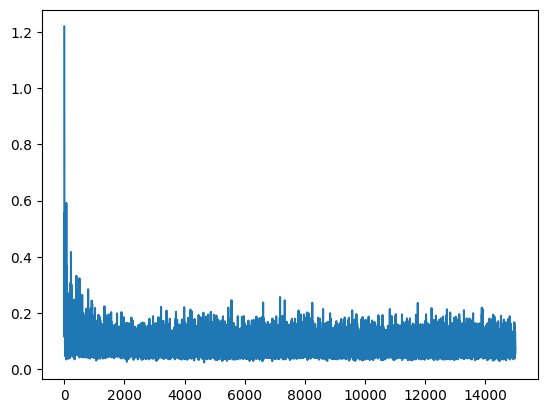

In [94]:
import matplotlib.pyplot as plt
p_x = range(rec_iter)
p_y = rec_loss
plt.plot(p_x,p_y)